<a href="https://colab.research.google.com/github/celalthedon/cnn-experiments/blob/main/U_net_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split, Subset

import torchvision
from torchvision.datasets import OxfordIIITPet
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode

In [53]:
@dataclass
class CFG:
  data_dir: Path = Path("data")
  output_dir: Path = Path("outputs")

  image_size: int = 128
  batch_size: int = 8
  num_workers: int = 2

  seed: int = 42
  lr: float = 1e-3
  epochs: int = 50

  #fast learning mode
  use_subset: bool = True
  subset_size: int = 500

CFG.output_dir.mkdir(parents = True, exist_ok=True)
CFG.data_dir.mkdir(parents = True, exist_ok=True)

In [3]:
#reproducibility
def set_seed(seed:int=42) ->None:
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed(seed)

  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False

set_seed(CFG.seed)

In [4]:
#device
def get_device() -> torch.device:
  if torch.cuda.is_available():
    return torch.device("cuda")
  if torch.backends.mps.is_available():
    return torch.device("mps")
  return torch.device("cpu")

device = get_device()
print(f"device is {device}")

device is cuda


In [5]:

trainval_raw = OxfordIIITPet(
    root = CFG.data_dir,
    split = "trainval",
    target_types= "segmentation",
    download = True
)

test_raw = OxfordIIITPet(
    root= CFG.data_dir,
    split = "test",
    target_types= "segmentation",
    download = True
)

print(f"Train size: {len(trainval_raw)}")
print(f"Test size: {len(test_raw)}")

100%|██████████| 792M/792M [00:06<00:00, 121MB/s]
100%|██████████| 19.2M/19.2M [00:00<00:00, 128MB/s] 


Train size: 3680
Test size: 3669


In [6]:
trainval_raw[0]

(<PIL.Image.Image image mode=RGB size=394x500>,
 <PIL.PngImagePlugin.PngImageFile image mode=L size=394x500>)

In [7]:
image, mask = trainval_raw[0]

print("Image size:", image.size)
print("Mask size :", mask.size)

Image size: (394, 500)
Mask size : (394, 500)


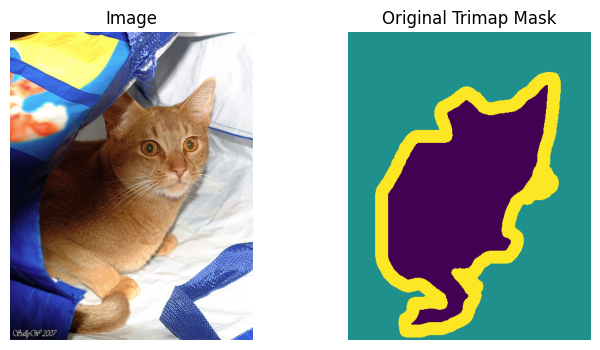

Mask unique values: [1 2 3]


In [8]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask)
plt.title("Original Trimap Mask")
plt.axis("off")

plt.show()

print("Mask unique values:", np.unique(np.array(mask)))

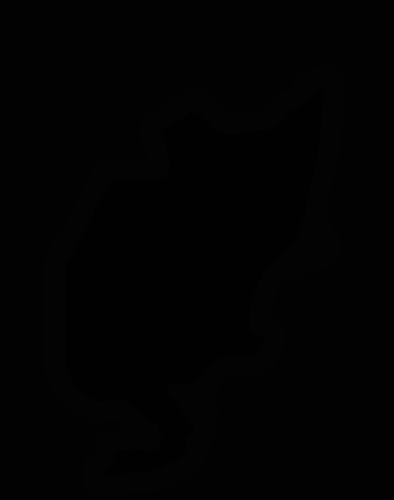

In [9]:
mask

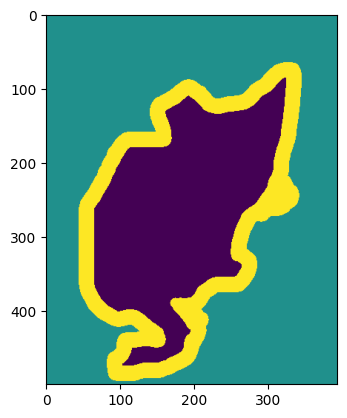

In [10]:
plt.imshow(mask)

In [11]:
class PetBinarySegmentationDataset(Dataset):
  def __init__(self, base_dataset, image_size: int = 128):
    self.base_dataset = base_dataset
    self.image_size = image_size

    self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    self.std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
  def __len__(self):
    return len(self.base_dataset)
  def __getitem__(self, index):
    image, mask = self.base_dataset[index]

    #mask resize
    mask = TF.resize(
        mask,
        size = [self.image_size, self.image_size],
        interpolation = InterpolationMode.NEAREST
    )

    #image resize
    image = TF.resize(
        image,
        size = [self.image_size, self.image_size],
        interpolation = InterpolationMode.BILINEAR
    )

    #image to tensor
    image = TF.to_tensor(image)

    #normalize
    image = (image - self.mean) / self.std

    #mask to numpy
    mask_np = np.array(mask)

    binary_mask = (mask_np !=2 ).astype(np.float32)

    binary_mask = torch.from_numpy(binary_mask).unsqueeze(0)

    return {
        "image": image.float(),
        "mask": binary_mask.float()
    }

In [12]:
full_trainval = PetBinarySegmentationDataset(
    trainval_raw,
    image_size = CFG.image_size
)

test_dataset = PetBinarySegmentationDataset(
    test_raw,
    image_size = CFG.image_size
)

if CFG.use_subest:
  indices =list(range(min(len(full_trainval), CFG.subset_size)))
  full_trainval = Subset(full_trainval, indices)

train_size = int(0.8*  len(full_trainval))
val_size = len(full_trainval) - train_size

train_dataset, val_dataset = random_split(full_trainval, [train_size, val_size], generator=torch.Generator().manual_seed(CFG.seed))

print("Train:", len(train_dataset))
print("Val  :", len(val_dataset))
print("Test :", len(test_dataset))

Train: 400
Val  : 100
Test : 3669


In [13]:
pin_memory = device.type == "cuda"

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG.batch_size,
    shuffle=True,
    num_workers=CFG.num_workers,
    pin_memory=pin_memory,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CFG.batch_size,
    shuffle=False,
    num_workers=CFG.num_workers,
    pin_memory=pin_memory,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CFG.batch_size,
    shuffle=False,
    num_workers=CFG.num_workers,
    pin_memory=pin_memory,
)

batch = next(iter(train_loader))

print("Image batch:", batch["image"].shape)
print("Mask batch :", batch["mask"].shape)
print("Image dtype:", batch["image"].dtype)
print("Mask dtype :", batch["mask"].dtype)
print("Mask unique:", torch.unique(batch["mask"]))

Image batch: torch.Size([8, 3, 128, 128])
Mask batch : torch.Size([8, 1, 128, 128])
Image dtype: torch.float32
Mask dtype : torch.float32
Mask unique: tensor([0., 1.])


In [14]:
def denormalize(image: torch.Tesor) -> torch.Tensor:
  mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
  std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
  return image * std + mean

batch = next(iter(train_loader))
images = batch["image"]
masks = batch["mask"]

In [15]:
num_show = min(4,images.size(0))

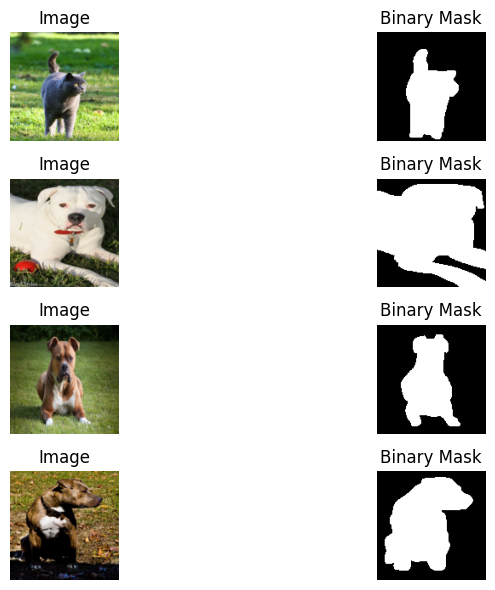

In [16]:
plt.figure(figsize=(10, 6))

for i in range(num_show):
    image = denormalize(images[i]).permute(1, 2, 0).clamp(0, 1)
    mask = masks[i, 0]

    plt.subplot(num_show, 2, 2 * i + 1)
    plt.imshow(image)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(num_show, 2, 2 * i + 2)
    plt.imshow(mask, cmap="gray")
    plt.title("Binary Mask")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1,
            bias=False,
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu1 = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1,
            bias=False,
        )
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu2 = nn.ReLU(inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)

        return x

In [18]:
class UNet(nn.Module):
    def __init__(self, in_channels: int = 3, out_channels: int = 1):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.enc2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.enc3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.enc4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Decoder
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        # Final 1x1 convolution
        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Encoder
        e1 = self.enc1(x)              # [B, 64, H, W]
        p1 = self.pool1(e1)            # [B, 64, H/2, W/2]

        e2 = self.enc2(p1)             # [B, 128, H/2, W/2]
        p2 = self.pool2(e2)            # [B, 128, H/4, W/4]

        e3 = self.enc3(p2)             # [B, 256, H/4, W/4]
        p3 = self.pool3(e3)            # [B, 256, H/8, W/8]

        e4 = self.enc4(p3)             # [B, 512, H/8, W/8]
        p4 = self.pool4(e4)            # [B, 512, H/16, W/16]

        # Bottleneck
        b = self.bottleneck(p4)        # [B, 1024, H/16, W/16]

        # Decoder + skip connections
        d4 = self.up4(b)               # [B, 512, H/8, W/8]
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)              # [B, 256, H/4, W/4]
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)              # [B, 128, H/2, W/2]
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)              # [B, 64, H, W]
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        logits = self.final_conv(d1)   # [B, 1, H, W]

        return logits

In [19]:
model = UNet(in_channels=3, out_channels=1).to(device)

In [20]:
batch = next(iter(train_loader))
images = batch["image"].to(device)
masks = batch["mask"].to(device)

In [21]:
with torch.no_grad():
    logits = model(images)

In [22]:
print("Images:", images.shape)
print("Masks :", masks.shape)
print("Logits:", logits.shape)

Images: torch.Size([8, 3, 128, 128])
Masks : torch.Size([8, 1, 128, 128])
Logits: torch.Size([8, 1, 128, 128])


In [23]:
criterion = nn.BCEWithLogitsLoss()

In [24]:
loss = criterion(logits, masks)

In [25]:
print("Initial loss:", loss.item())

Initial loss: 0.7301976680755615


In [26]:
def dice_score_from_logits(
    logits: torch.Tensor,
    targets: torch.Tensor,
    treshold: float = 0.5,
    eps: float = 1e-7,
) -> torch.Tensor:

  probs = torch.sigmoid(logits)
  preds = (probs >treshold).float()

  preds = preds.view(preds.size(0), -1)
  targets = targets.view(targets.size(0), -1)

  intersection = (preds * targets).sum(dim=1)
  union = preds.sum(dim=1) + targets.sum(dim=1)

  dice = (2.0 * intersection + eps) / (union + eps)

  return dice.mean()

In [27]:
dice = dice_score_from_logits(logits, masks)

In [28]:
print("Initial Dice:", dice.item())

Initial Dice: 0.40116167068481445


In [30]:
class DiceLoss(nn.Module):
    def __init__(self, smooth: float = 1e-7):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        probs = torch.sigmoid(logits)

        probs = probs.reshape(probs.size(0), -1)
        targets = targets.reshape(targets.size(0), -1)

        intersection = (probs * targets).sum(dim=1)
        denominator = probs.sum(dim=1) + targets.sum(dim=1)

        dice = (2.0 * intersection + self.smooth) / (denominator + self.smooth)

        loss = 1.0 - dice

        return loss.mean()

In [31]:
bce_loss_fn = nn.BCEWithLogitsLoss()
doce_loss_fn = DiceLoss()

In [32]:
def bce_dice_loss(
    logits: torch.Tensor,
    targets: torch.Tensor,
    bce_weight: float = 0.5,
    dice_weight: float = 0.5,
) -> torch.Tensor:
  bce = bce_loss_fn(logits, targets)
  dice = doce_loss_fn(logits, targets)
  loss = bce_weight * bce + dice_weight * dice
  return loss

In [33]:
def iou_score_from_logits(
    logits: torch.Tensor,
    targets: torch.Tensor,
    threshold: float = 0.5,
    eps: float = 1e-7,
) -> torch.Tensor:
  probs = torch.sigmoid(logits)
  preds = (probs > threshold).float()

  preds = preds.reshape(preds.size(0), -1)
  targets = targets.reshape(targets.size(0), -1)

  intersection = (preds * targets).sum(dim=1)
  pred_area = preds.sum(dim=1)
  target_area = targets.sum(dim=1)
  union = pred_area + target_area - intersection

  iou = (intersection + eps) / (union + eps)

  return iou.mean()

In [34]:
model = UNet(in_channels=3, out_channels=1).to(device)

In [35]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG.lr,
    weight_decay=1e-4,
)

In [36]:
print("Model parameters:", sum(p.numel() for p in model.parameters()) / 1e6, "M")

Model parameters: 31.037633 M


In [37]:
debug_model = UNet(in_channels=3, out_channels=1).to(device)

debug_optimizer = torch.optim.AdamW(
    debug_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

debug_batch = next(iter(train_loader))

debug_images = debug_batch["image"].to(device, non_blocking=True)
debug_masks = debug_batch["mask"].to(device, non_blocking=True)

debug_model.train()

for step in range(30):
    debug_optimizer.zero_grad(set_to_none=True)

    debug_logits = debug_model(debug_images)
    debug_loss = bce_dice_loss(debug_logits, debug_masks)

    debug_loss.backward()
    debug_optimizer.step()

    if (step + 1) % 5 == 0:
        with torch.no_grad():
            debug_dice = dice_score_from_logits(debug_logits, debug_masks)
            debug_iou = iou_score_from_logits(debug_logits, debug_masks)

        print(
            f"Step {step+1:02d} | "
            f"Loss: {debug_loss.item():.4f} | "
            f"Dice: {debug_dice.item():.4f} | "
            f"IoU: {debug_iou.item():.4f}"
        )

Step 05 | Loss: 0.4476 | Dice: 0.6822 | IoU: 0.5493
Step 10 | Loss: 0.2810 | Dice: 0.8775 | IoU: 0.7930
Step 15 | Loss: 0.1894 | Dice: 0.9386 | IoU: 0.8851
Step 20 | Loss: 0.1572 | Dice: 0.9527 | IoU: 0.9099
Step 25 | Loss: 0.1309 | Dice: 0.9618 | IoU: 0.9267
Step 30 | Loss: 0.1092 | Dice: 0.9716 | IoU: 0.9448


In [38]:
def train_one_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
) -> dict:
    model.train()

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0

    num_batches = len(dataloader)

    for batch_idx, batch in enumerate(dataloader):
        images = batch["image"].to(device, non_blocking=True)
        masks = batch["mask"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)
        loss = bce_dice_loss(logits, masks)

        loss.backward()
        optimizer.step()

        with torch.no_grad():
            dice = dice_score_from_logits(logits, masks)
            iou = iou_score_from_logits(logits, masks)

        total_loss += loss.item()
        total_dice += dice.item()
        total_iou += iou.item()

    return {
        "loss": total_loss / num_batches,
        "dice": total_dice / num_batches,
        "iou": total_iou / num_batches,
    }

In [39]:
@torch.no_grad()
def validate_one_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    device: torch.device,
) -> dict:
    model.eval()

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0

    num_batches = len(dataloader)

    for batch in dataloader:
        images = batch["image"].to(device, non_blocking=True)
        masks = batch["mask"].to(device, non_blocking=True)

        logits = model(images)
        loss = bce_dice_loss(logits, masks)

        dice = dice_score_from_logits(logits, masks)
        iou = iou_score_from_logits(logits, masks)

        total_loss += loss.item()
        total_dice += dice.item()
        total_iou += iou.item()

    return {
        "loss": total_loss / num_batches,
        "dice": total_dice / num_batches,
        "iou": total_iou / num_batches,
    }

In [43]:
def get_config_dict() -> dict:
    return {
        "data_dir": str(CFG.data_dir),
        "output_dir": str(CFG.output_dir),
        "image_size": CFG.image_size,
        "batch_size": CFG.batch_size,
        "num_workers": CFG.num_workers,
        "seed": CFG.seed,
        "lr": CFG.lr,
        "epochs": CFG.epochs,
        "use_subset": CFG.use_subset,
        "subset_size": CFG.subset_size,
    }

In [54]:
best_val_dice = -1.0

history = {
    "train_loss": [],
    "train_dice": [],
    "train_iou": [],
    "val_loss": [],
    "val_dice": [],
    "val_iou": [],
}

best_model_path = CFG.output_dir / "unet_pet_segmentation_best.pth"

for epoch in range(CFG.epochs):
    print(f"\nEpoch {epoch + 1}/{CFG.epochs}")
    print("-" * 60)

    train_metrics = train_one_epoch(
        model=model,
        dataloader=train_loader,
        optimizer=optimizer,
        device=device,
    )

    val_metrics = validate_one_epoch(
        model=model,
        dataloader=val_loader,
        device=device,
    )

    history["train_loss"].append(train_metrics["loss"])
    history["train_dice"].append(train_metrics["dice"])
    history["train_iou"].append(train_metrics["iou"])

    history["val_loss"].append(val_metrics["loss"])
    history["val_dice"].append(val_metrics["dice"])
    history["val_iou"].append(val_metrics["iou"])

    print(
        f"Train | "
        f"Loss: {train_metrics['loss']:.4f} | "
        f"Dice: {train_metrics['dice']:.4f} | "
        f"IoU: {train_metrics['iou']:.4f}"
    )

    print(
        f"Val   | "
        f"Loss: {val_metrics['loss']:.4f} | "
        f"Dice: {val_metrics['dice']:.4f} | "
        f"IoU: {val_metrics['iou']:.4f}"
    )

    if val_metrics["dice"] > best_val_dice:
        best_val_dice = val_metrics["dice"]

        torch.save(
          {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_dice": best_val_dice,
            "config": get_config_dict(),
          },
          best_model_path,
        )

        print(f"Saved best model with val Dice: {best_val_dice:.4f}")

print("\nTraining complete.")
print("Best val Dice:", best_val_dice)
print("Best model path:", best_model_path)


Epoch 1/50
------------------------------------------------------------
Train | Loss: 0.0542 | Dice: 0.9643 | IoU: 0.9320
Val   | Loss: 0.2967 | Dice: 0.8578 | IoU: 0.7697
Saved best model with val Dice: 0.8578

Epoch 2/50
------------------------------------------------------------
Train | Loss: 0.0542 | Dice: 0.9642 | IoU: 0.9317
Val   | Loss: 0.3043 | Dice: 0.8521 | IoU: 0.7606

Epoch 3/50
------------------------------------------------------------
Train | Loss: 0.0533 | Dice: 0.9647 | IoU: 0.9328
Val   | Loss: 0.3096 | Dice: 0.8515 | IoU: 0.7616

Epoch 4/50
------------------------------------------------------------
Train | Loss: 0.0510 | Dice: 0.9662 | IoU: 0.9355
Val   | Loss: 0.2992 | Dice: 0.8490 | IoU: 0.7562

Epoch 5/50
------------------------------------------------------------
Train | Loss: 0.0517 | Dice: 0.9657 | IoU: 0.9346
Val   | Loss: 0.2936 | Dice: 0.8533 | IoU: 0.7630

Epoch 6/50
------------------------------------------------------------
Train | Loss: 0.0505 | 

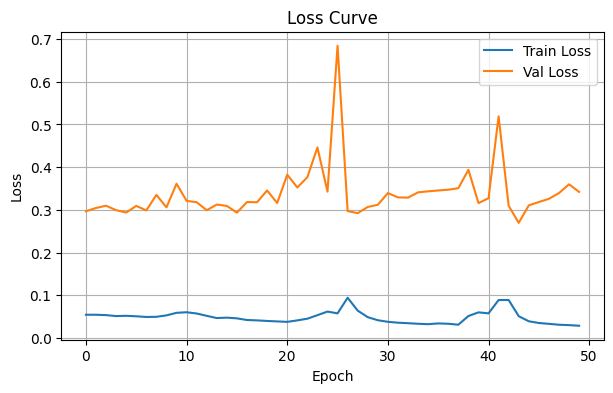

In [55]:
plt.figure(figsize=(7, 4))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

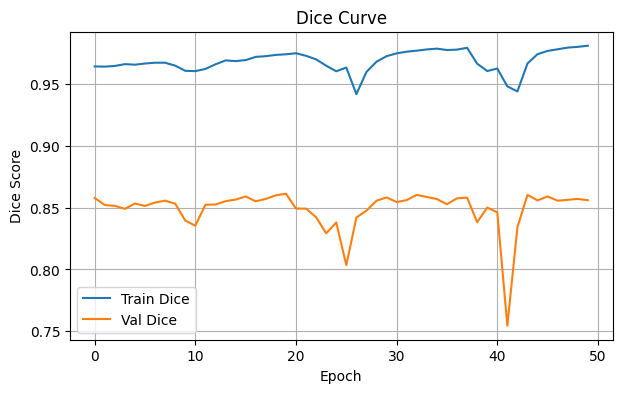

In [56]:
plt.figure(figsize=(7, 4))
plt.plot(history["train_dice"], label="Train Dice")
plt.plot(history["val_dice"], label="Val Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Dice Curve")
plt.legend()
plt.grid(True)
plt.show()

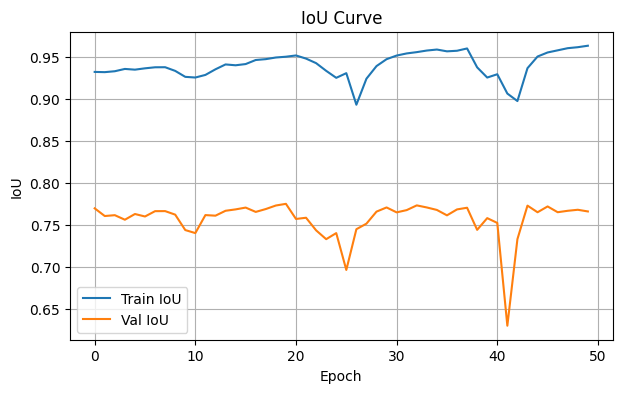

In [57]:
plt.figure(figsize=(7, 4))
plt.plot(history["train_iou"], label="Train IoU")
plt.plot(history["val_iou"], label="Val IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("IoU Curve")
plt.legend()
plt.grid(True)
plt.show()

In [58]:
checkpoint = torch.load(best_model_path, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

print("Loaded best model from epoch:", checkpoint["epoch"])
print("Best val Dice:", checkpoint["best_val_dice"])

Loaded best model from epoch: 20
Best val Dice: 0.8612598410019507


In [59]:
@torch.no_grad()
def visualize_predictions(
    model: nn.Module,
    dataloader: DataLoader,
    device: torch.device,
    num_samples: int = 4,
    threshold: float = 0.5,
) -> None:
    model.eval()

    batch = next(iter(dataloader))

    images = batch["image"].to(device)
    masks = batch["mask"].to(device)

    logits = model(images)
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    images = images.cpu()
    masks = masks.cpu()
    probs = probs.cpu()
    preds = preds.cpu()

    num_samples = min(num_samples, images.size(0))

    plt.figure(figsize=(12, num_samples * 3))

    for i in range(num_samples):
        image = denormalize(images[i]).permute(1, 2, 0).clamp(0, 1)
        true_mask = masks[i, 0]
        prob_mask = probs[i, 0]
        pred_mask = preds[i, 0]

        plt.subplot(num_samples, 4, 4 * i + 1)
        plt.imshow(image)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(num_samples, 4, 4 * i + 2)
        plt.imshow(true_mask, cmap="gray")
        plt.title("True Mask")
        plt.axis("off")

        plt.subplot(num_samples, 4, 4 * i + 3)
        plt.imshow(prob_mask, cmap="gray")
        plt.title("Pred Probability")
        plt.axis("off")

        plt.subplot(num_samples, 4, 4 * i + 4)
        plt.imshow(pred_mask, cmap="gray")
        plt.title("Pred Mask")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

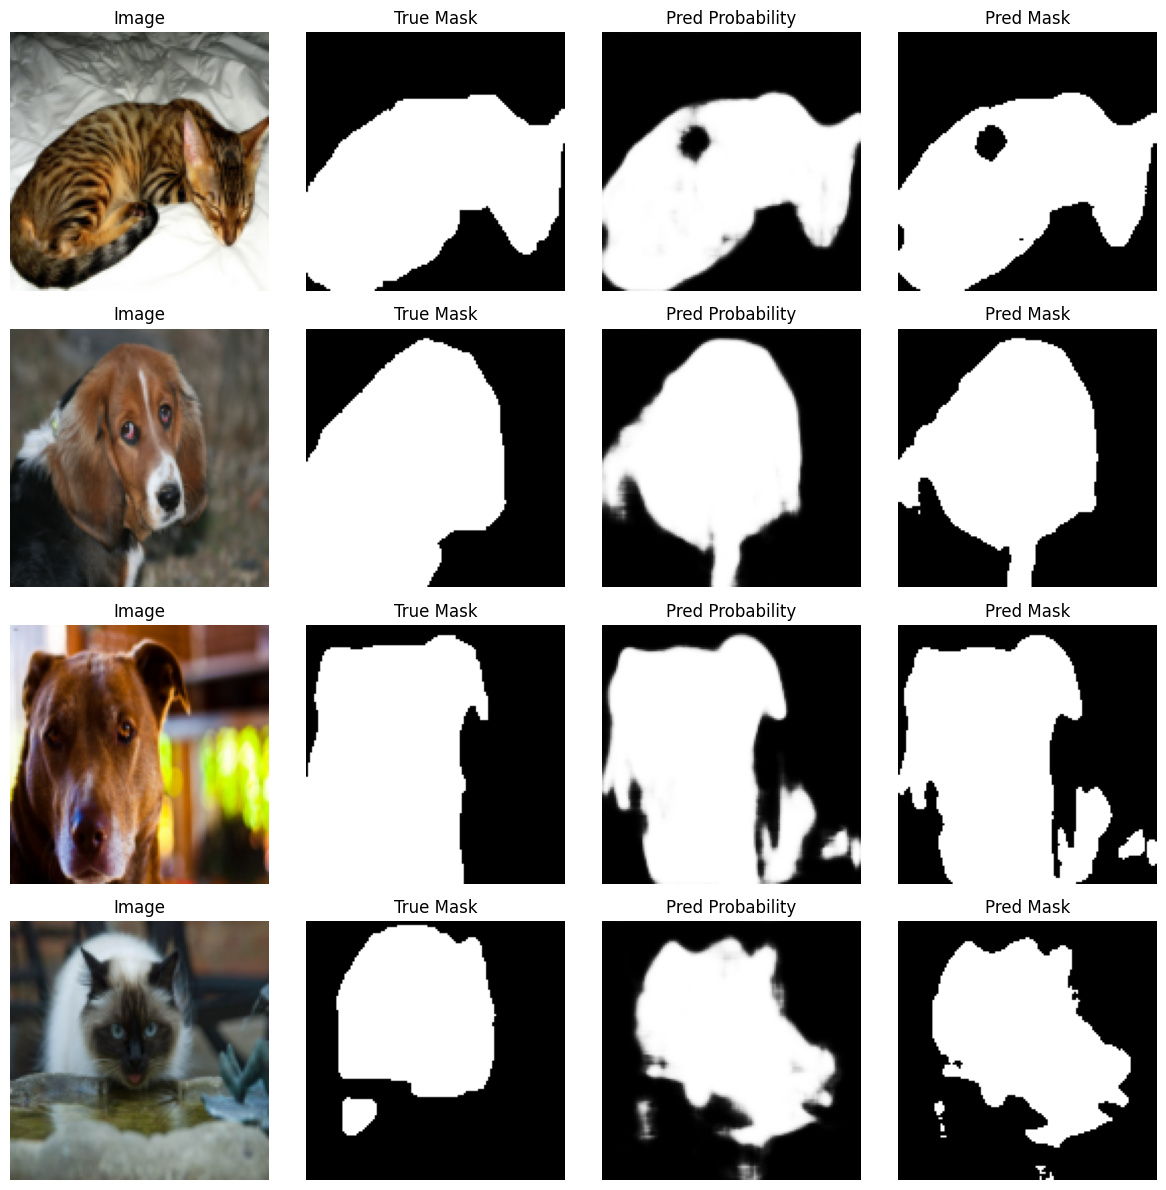

In [60]:
visualize_predictions(
    model=model,
    dataloader=val_loader,
    device=device,
    num_samples=4,
    threshold=0.5,
)

In [61]:
@torch.no_grad()
def visualize_overlay_predictions(
    model: nn.Module,
    dataloader: DataLoader,
    device: torch.device,
    num_samples: int = 4,
    threshold: float = 0.5,
    alpha: float = 0.45,
) -> None:
    model.eval()

    batch = next(iter(dataloader))

    images = batch["image"].to(device)
    masks = batch["mask"].to(device)

    logits = model(images)
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    images = images.cpu()
    masks = masks.cpu()
    preds = preds.cpu()

    num_samples = min(num_samples, images.size(0))

    plt.figure(figsize=(12, num_samples * 3))

    for i in range(num_samples):
        image = denormalize(images[i]).permute(1, 2, 0).clamp(0, 1).numpy()
        true_mask = masks[i, 0].numpy()
        pred_mask = preds[i, 0].numpy()

        true_overlay = image.copy()
        pred_overlay = image.copy()

        true_overlay[..., 1] = np.maximum(true_overlay[..., 1], true_mask * alpha)
        pred_overlay[..., 0] = np.maximum(pred_overlay[..., 0], pred_mask * alpha)

        plt.subplot(num_samples, 3, 3 * i + 1)
        plt.imshow(image)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(num_samples, 3, 3 * i + 2)
        plt.imshow(true_overlay)
        plt.title("True Overlay")
        plt.axis("off")

        plt.subplot(num_samples, 3, 3 * i + 3)
        plt.imshow(pred_overlay)
        plt.title("Pred Overlay")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

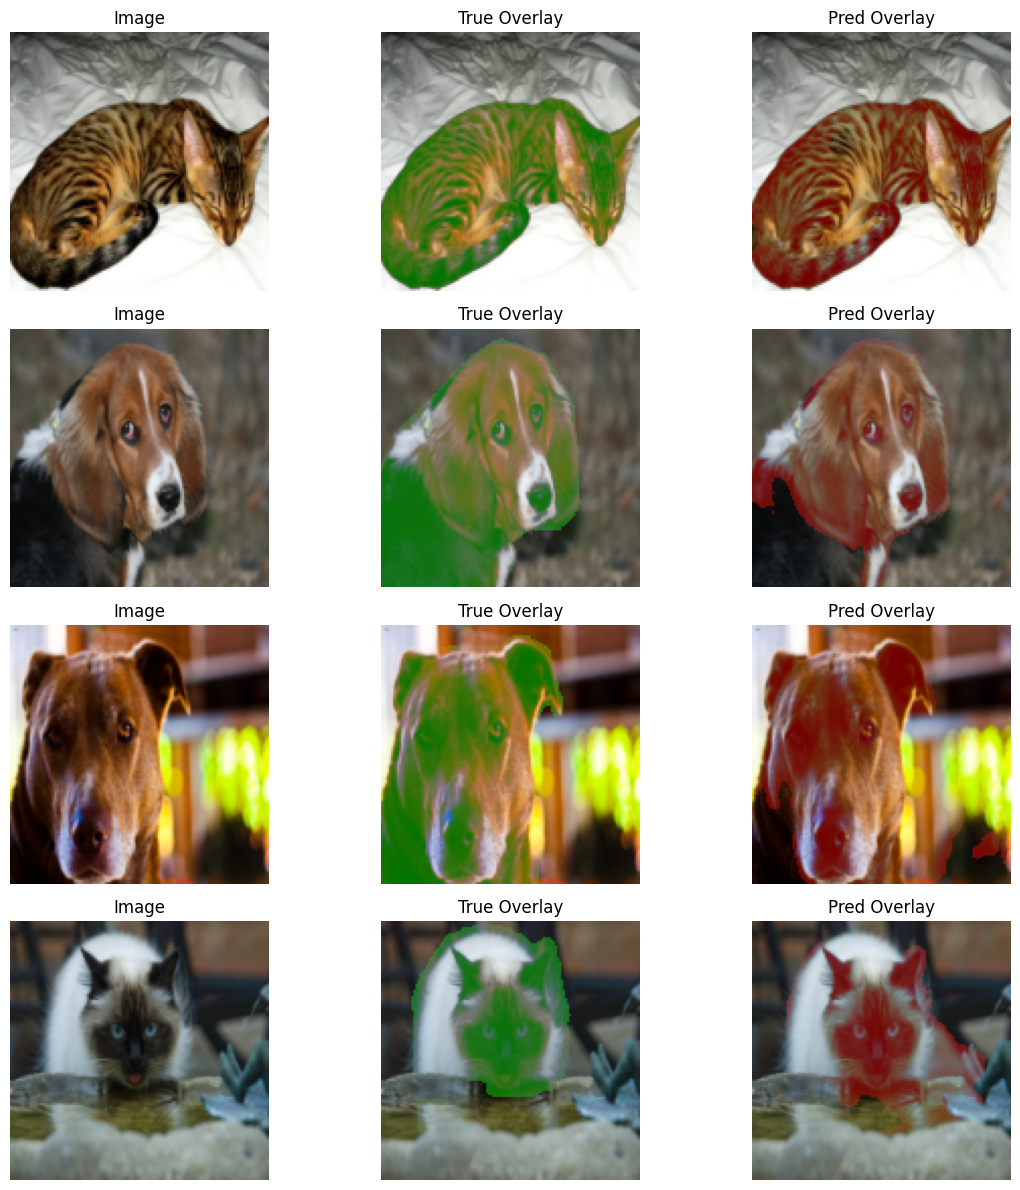

In [62]:
visualize_overlay_predictions(
    model=model,
    dataloader=val_loader,
    device=device,
    num_samples=4,
    threshold=0.5,
)

In [63]:
test_metrics = validate_one_epoch(
    model=model,
    dataloader=test_loader,
    device=device,
)

print("Test results")
print("-" * 40)
print(f"Loss: {test_metrics['loss']:.4f}")
print(f"Dice: {test_metrics['dice']:.4f}")
print(f"IoU : {test_metrics['iou']:.4f}")

Test results
----------------------------------------
Loss: 0.3396
Dice: 0.8610
IoU : 0.7710
